In [5]:
import cv2
import numpy as np
import tensorflow as tf
from IPython.display import display, Image, clear_output
import ipywidgets as widgets

In [2]:
model = tf.keras.models.load_model('person_segmentation_model.keras')
IMG_SIZE = 128

I0000 00:00:1773574263.847682  312790 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2792 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
2026-03-15 13:31:10.813671: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 20054016 exceeds 10% of free system memory.
2026-03-15 13:31:11.021219: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 20054016 exceeds 10% of free system memory.
2026-03-15 13:31:11.338661: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 20054016 exceeds 10% of free system memory.


In [3]:
stop_button = widgets.Button(description="Stop", button_style='danger')
stop = {'clicked': False}
stop_button.on_click(lambda b: stop.update({'clicked': True}))
display(stop_button)

img_widget = widgets.Image(format='jpeg')
display(img_widget)

cap = cv2.VideoCapture(0)

while not stop['clicked']:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess
    resized      = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    rgb          = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    input_tensor = tf.keras.applications.mobilenet_v2.preprocess_input(
                       rgb.astype(np.float32))
    input_tensor = np.expand_dims(input_tensor, axis=0)

    # Predict
    pred      = model.predict(input_tensor, verbose=0)
    pred_mask = np.argmax(pred[0], axis=-1).astype(np.uint8)  # (128, 128)

    # Resize mask to original frame size
    h, w      = frame.shape[:2]
    pred_mask = cv2.resize(pred_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    # Green
    overlay             = frame.copy()
    overlay[pred_mask == 1] = [0, 255, 0]
    output              = cv2.addWeighted(frame, 0.6, overlay, 0.4, 0)

    # Contours
    contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(output, contours, -1, (0, 255, 0), 2)

    # Encode to JPEG and push to widget
    _, buffer     = cv2.imencode('.jpg', output)
    img_widget.value = buffer.tobytes()

cap.release()
print("Camera released.")

Button(button_style='danger', description='Stop', style=ButtonStyle())

Image(value=b'', format='jpeg')

2026-03-15 13:31:20.500635: I external/local_xla/xla/service/service.cc:163] XLA service 0x7311e4004eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-15 13:31:20.500650: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-03-15 13:31:20.683309: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-15 13:31:21.630238: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-15 13:31:28.270840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 13:31:28.392991: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: 

KeyboardInterrupt: 

In [4]:
cap.release()
print("Camera released.")

Camera released.


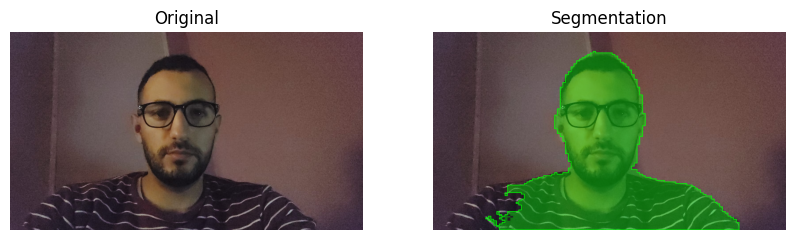

True

In [11]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('person_segmentation_model.keras')
IMG_SIZE = 128

frame = cv2.imread('./for.jpeg')

if frame is None:
    raise ValueError("Image not found")

# preprocess
resized = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

input_tensor = tf.keras.applications.mobilenet_v2.preprocess_input(
    rgb.astype(np.float32)
)
input_tensor = np.expand_dims(input_tensor, axis=0)

# prediction
pred = model.predict(input_tensor, verbose=0)

# try sigmoid threshold first
if pred.shape[-1] == 1:
    pred_mask = (pred[0,:,:,0] > 0.5).astype(np.uint8)
else:
    pred_mask = np.argmax(pred[0], axis=-1).astype(np.uint8)

# resize mask
h, w = frame.shape[:2]
pred_mask = cv2.resize(pred_mask, (w, h), interpolation=cv2.INTER_NEAREST)

# overlay
overlay = frame.copy()
overlay[pred_mask == 1] = [0,255,0]

output = cv2.addWeighted(frame, 0.6, overlay, 0.4, 0)

# contours
contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(output, contours, -1, (0,255,0), 2)

# display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Segmentation")
plt.axis("off")

plt.show()

cv2.imwrite("output.jpg", output)
